In [1]:
import sys
from pathlib import Path

root_path = Path.cwd().parent.parent

sys.path.append(str(root_path))
params_path = root_path / "params/"

import matplotlib.pyplot as plt
import numpy as np

from domain.functions import double_exp, single_exp
from plotting.plot_style import plot_style
from src.ls_multiple_inits import fit_ls
from utils.sampling.sampling_autocorr import sample_double_exp, sample_single_exp
from utils.seed import set_seed

In [2]:
set_seed(123)

# Generate noisy data

In [3]:
# Gaussian
true_gamma_1 = 1
true_gamma_2 = 6
true_A1 = 0.3
n = 2000
time_lags = np.linspace(0, 10, n)


# Single exponential decay noisy data
data_single_decay = sample_single_exp(gamma=true_gamma_1, t=time_lags, noise_std=0.05)

# Double exponential decay noisy data
data_double_decay = sample_double_exp(
    A1=true_A1, gamma1=true_gamma_1, gamma2=true_gamma_2, t=time_lags, noise_std=0.05
)

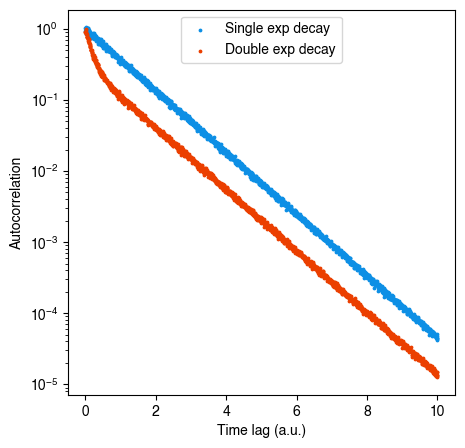

In [4]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.scatter(
        time_lags, data_single_decay, color=colors[0], s=3, label="Single exp decay"
    )
    ax.scatter(
        time_lags, data_double_decay, color=colors[1], s=3, label="Double exp decay"
    )

    ax.set_yscale("log")
    ax.set_xlabel("Time lag (a.u.)")
    ax.set_ylabel("Autocorrelation")

    ax.legend(loc="upper center")

    plt.show()

# Least-squares fit

In [5]:
param_init = [1]  # to run with multiple inits pass [<val>, <val>, ...]

result_single_exp = fit_ls(
    model="single_exp",
    x=time_lags,
    y=data_single_decay,
    p0_list=param_init,
    bounds=([1e-6], [np.inf]),
    verbose=True,
)

In [6]:
param_init = [
    [0.1, 1, 1]
]  # to run with multiple inits pass [[<val>, <val>, <val>], ...]

result_double_exp = fit_ls(
    model="double_exp",
    x=time_lags,
    y=data_double_decay,
    p0_list=param_init,
    bounds=([1e-6, 1e-6, 1e-6], [0.999, np.inf, np.inf]),
    verbose=True,
)

In [7]:
gamma_fit = result_single_exp["gamma"]

single_exp_fit = single_exp(time_lags, gamma=gamma_fit)

In [8]:
A1_fit = result_double_exp["A1"]
gamma1_fit = result_double_exp["gamma1"]
gamma2_fit = result_double_exp["gamma2"]

double_exp_fit = double_exp(time_lags, A1=A1_fit, gamma1=gamma1_fit, gamma2=gamma2_fit)

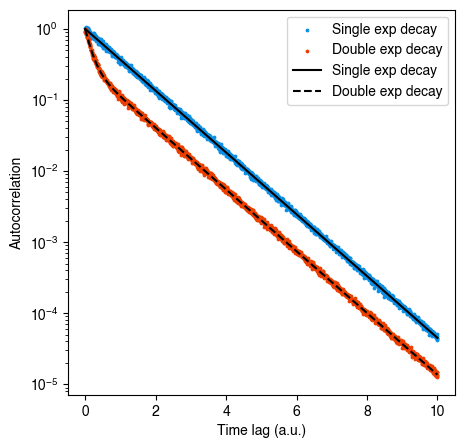

In [9]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.scatter(
        time_lags, data_single_decay, color=colors[0], s=3, label="Single exp decay"
    )
    ax.scatter(
        time_lags, data_double_decay, color=colors[1], s=3, label="Double exp decay"
    )

    ax.plot(time_lags, single_exp_fit, color="black", lw=1.5, label="Single exp decay")
    ax.plot(
        time_lags,
        double_exp_fit,
        color="black",
        lw=1.5,
        ls="dashed",
        label="Double exp decay",
    )

    ax.set_yscale("log")
    ax.set_xlabel("Time lag (a.u.)")
    ax.set_ylabel("Autocorrelation")

    ax.legend(loc="upper right")

    plt.show()